# Lab 13

In [5]:
import requests
from openai import OpenAI

# those settings use vLLM server
client = OpenAI(api_key="EMPTY", base_url="http://localhost:8000/v1")

def generate(prompt: str):
    chat_response = client.chat.completions.create(
        model="",  # use the default server model
        messages=[
            {"role": "developer", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt},
        ],
        max_completion_tokens=1000,
        # turn off thinking for Qwen with /no_think
        extra_body={"chat_template_kwargs": {"enable_thinking": True}}
    )
    return chat_response

## Quantization Benchmark

We were asked to compare the performance between full precision Qwen3 model and its 4-bit quantized version using bitsandbytes.

However, instead of comparing serving time I decided to measure throughput, as serving time may differ based on the output length, which will vary betweend respsonses.

In [6]:
# 10 quite-easy prompts to test the model
prompts = [
    "Write a Python function that calculates the factorial of a number.",
    "Explain the concept of polymorphism in object-oriented programming.",
    "What are the main differences between Python and Java?",
    "Create a simple HTML page with a header, paragraph, and a link.",
    "Describe the process of normalization in database design.",
    "Write a SQL query to find all employees with a salary greater than 50000.",
    "What is the purpose of unit testing in software development?",
    "Explain the difference between synchronous and asynchronous programming.",
    "Create a CSS rule to center-align text within a div element.",
    "What are RESTful APIs and why are they important in web development?"
]

In [11]:
import time

start_time = time.time()
total_tokens = 0
for i, prompt in enumerate(prompts):
    response = generate(prompt)
    total_tokens += response.usage.total_tokens

qwen3_full_time = total_tokens / (time.time() - start_time)
print(f"Qwen 3 (Full precision) TPS: {qwen3_full_time:.2f} seconds")

Qwen 3 (Full precision) TPS: 107.66 seconds


In [14]:
import time

start_time = time.time()
total_tokens = 0
for i, prompt in enumerate(prompts):
    response = generate(prompt)
    total_tokens += response.usage.total_tokens

qwen3_bnb_time = total_tokens / (time.time() - start_time)
print(f"Qwen 3 (Unsloth 4-bit bnb) TPS: {qwen3_bnb_time:.2f} seconds")

Qwen 3 (Unsloth 4-bit bnb) TPS: 185.72 seconds


In [15]:
qwen3_full_memory = 66288
qwen3_bnb_kv_cache = 78832

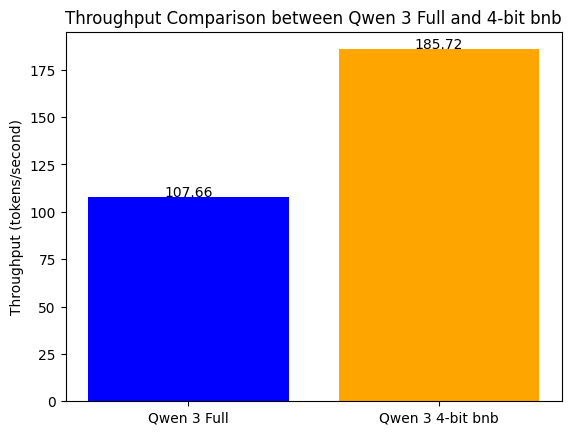

In [16]:
import matplotlib.pyplot as plt

labels = ['Qwen 3 Full', 'Qwen 3 4-bit bnb']
throughputs = [qwen3_full_time, qwen3_bnb_time]
x = range(len(labels))
plt.bar(x, throughputs, color=['blue', 'orange'])
plt.xticks(x, labels)
plt.ylabel('Throughput (tokens/second)')
plt.title('Throughput Comparison between Qwen 3 Full and 4-bit bnb')
for i, v in enumerate(throughputs):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center')
plt.show()

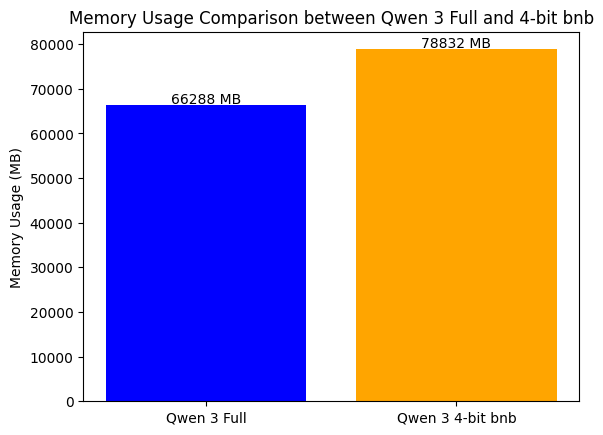

In [17]:
plt.bar(x, [qwen3_full_memory, qwen3_bnb_kv_cache], color=['blue', 'orange'])
plt.xticks(x, labels)
plt.ylabel('Memory Usage (MB)')
plt.title('Memory Usage Comparison between Qwen 3 Full and 4-bit bnb')
for i, v in enumerate([qwen3_full_memory, qwen3_bnb_kv_cache]):
    plt.text(i, v + 500, f"{v} MB", ha='center')
plt.show()

Quantized model was nearly 2x faster in terms of throughput and in the same memory budget was able to fit 12k (~1.4 GB) more tokens in KV cache.